In [ ]:
import pandas as pd
from datetime import datetime, timedelta

import solarsystem
print(solarsystem.__version__)
from solarsystem.functions import normalize, demical2arcs

from skyfield.api import load, wgs84
from skyfield import almanac

from skyfield.api import N, S, E, W, load, wgs84

import matplotlib.pyplot as plt
import numpy as np

0.1.8


In [ ]:
N, S, E, W

(1.0, -1.0, 1.0, -1.0)

In [ ]:
# --------------------------------------------------
# HELPERS
# --------------------------------------------------

def minutes_abs_difference(t1, t2):
    """Return absolute time difference in minutes."""
    return abs((t1 - t2).total_seconds()) / 60.0
def minutes_difference(t1, t2):
    """Return time difference in minutes."""
    return ((t1 - t2).total_seconds()) / 60.0

In [ ]:

# --------------------------------------------------
# USER CONFIGURATION
# --------------------------------------------------

# setting 1
# LATITUDE = 51.4934      # Greenwich
# LONGITUDE = 0.0098
# NORTH=True
# EAST=True

# setting 2
LATITUDE = 37.98      # Athens
LONGITUDE = 23.73

NORTH=True # set to False for South Longitudes
EAST=True # set to False fot West Latitudes


YEAR = 2025
MONTH = 1
DAY = 1

# number of validation days
N_DAYS = 365



In [ ]:

if NORTH==False:
    LATITUDE *= -1
if EAST==False:
    LONGITUDE *= -1

In [ ]:
LONGITUDE,LATITUDE

(23.73, 37.98)

In [ ]:
YEAR, MONTH, DAY

(2025, 1, 1)

In [ ]:
# ------------------------------------------------------------
# COMPARISON - ONCE PER DAY (at 12 noon) FOR A SINGLE YEAR
# ***************** topographic=True *********************
# Metric: MAE (Mean Absolute Error)
# ------------------------------------------------------------

HOUR, MINUTE = 12, 0
print(YEAR, MONTH, DAY)
d=datetime(YEAR, MONTH, DAY, HOUR, MINUTE, 0)
eph = load('de440.bsp')
# eph = load('de440s.bsp')

resLon=[]
resLat=[]
resMDist=[]
resMDistPC=[]
for nd in (range(365)):
    f = d + timedelta(days=nd)

    # ==========================================
    # # solarsystem Moon
    # ==========================================

    ss_moon = solarsystem.Moon(year=f.year, month=f.month, day=f.day, hour=12, minute=0,
                         UT=0, dst=0, longtitude=LONGITUDE, latitude=LATITUDE, topographic=True)

    moon_lon, moon_lat, moon_r = ss_moon.position()


    # ==========================================
    # # skyfield moon
    # ==========================================

    ts = load.timescale()
    t = ts.utc(f.year, f.month, f.day, HOUR, MINUTE)

    location = wgs84.latlon(LATITUDE , LONGITUDE )
    # location = wgs84.latlon(LATITUDE , LONGITUDE, elevation_m=-6500000 )

    observer = eph['Earth'] + location


    moon = eph['Moon']
    # t0 = ts.utc(f.year, f.month, f.day, 12)
    # t1 = ts.utc(f.year, f.month, f.day+2)

    apparent = observer.at(t).observe(moon).apparent()

    lat_sk= apparent.ecliptic_latlon(epoch=t)[0].degrees
    lon_sk= apparent.ecliptic_latlon(epoch=t)[1].degrees
    dist_sk= apparent.ecliptic_latlon(epoch=t)[2].au

    # ==========================================
    # errors
    # ==========================================
    moon_lon=normalize(moon_lon)
    lon_sk=normalize(lon_sk)

    moon_r=moon_r*(6378127)/1.496e+11

    lon_error = abs(moon_lon - lon_sk)
    # lon_error = (moon_lon - lon_sk)

    lat_error = abs(moon_lat - lat_sk)
    # lat_error = (moon_lat - lat_sk)

    dist_error = abs(moon_r - dist_sk)
    # dist_error = (moon_r - dist_sk)
    dist_error_pc=100*dist_error/dist_sk



    resLon.append(lon_error)
    resLat.append(lat_error)
    resMDist.append(dist_error)
    resMDistPC.append(dist_error_pc)


2025 1 1


In [ ]:
print('Moon Longitude MAE mean:', np.round(np.array(resLon).mean(),6), 'degrees')
print('Moon Longitude MAE max :', np.round(np.array(resLon).max(),6), 'degrees')
print('Moon Longitude MAE std :', np.round(np.array(resLon).std(),6), 'degrees')
print('-----------------------------------------')
print('Moon Latitude MAE  mean:', np.round(np.array(resLat).mean(),6), 'degrees')
print('Moon Latitude MAE  max :', np.round(np.array(resLat).max(),6), 'degrees')
print('Moon Latitude MAE  std :', np.round(np.array(resLat).std(),6), 'degrees')
print('-----------------------------------------')
print('Moon distance MAE  mean:', np.round(np.array(resMDist).mean(),12), 'AU')
print('Moon distance MAE  max :', np.round(np.array(resMDist).max(),12), 'AU')
print('Moon distance MAE  std :', np.round(np.array(resMDist).std(),12), 'AU')

print('Moon distance MAE  mean PC:', np.round(np.array(resMDistPC).mean(),12), '%')
# print('Moon distance MAE  mean:', np.round(100*np.array(resMDist).mean()/dist_sk,12), '%')


Moon Longitude MAE mean: 0.023342 degrees
Moon Longitude MAE max : 0.07226 degrees
Moon Longitude MAE std : 0.015421 degrees
-----------------------------------------
Moon Latitude MAE  mean: 0.015548 degrees
Moon Latitude MAE  max : 0.048329 degrees
Moon Latitude MAE  std : 0.010309 degrees
-----------------------------------------
Moon distance MAE  mean: 2.0458341e-05 AU
Moon distance MAE  max : 4.1529222e-05 AU
Moon distance MAE  std : 1.1512199e-05 AU
Moon distance MAE  mean PC: 0.797285762572 %


In [ ]:
print('lon',demical2arcs(np.array(resLon).mean()),demical2arcs(np.array(resLon).max()),demical2arcs(np.array(resLon).std()))
print('lat',demical2arcs(np.array(resLat).mean()),demical2arcs(np.array(resLat).max()),demical2arcs(np.array(resLat).std()))

lon 0° 1.4' 0° 4.34' 0° 0.93'
lat 0° 0.93' 0° 2.9' 0° 0.62'


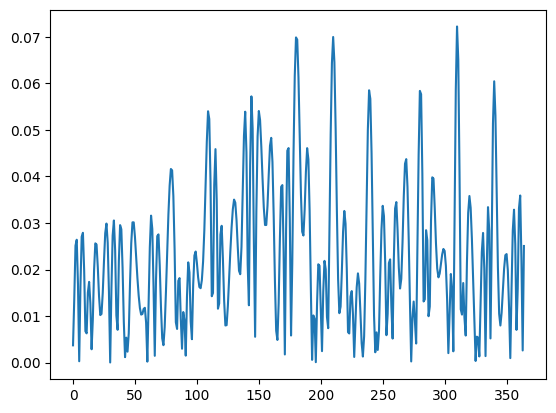

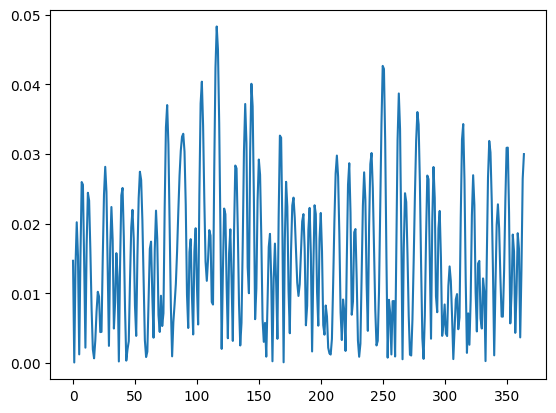

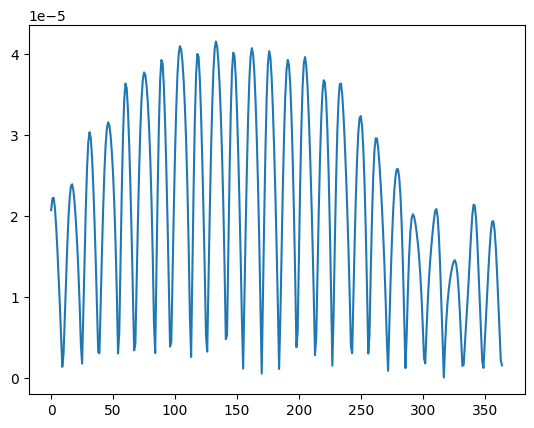

In [ ]:

# moon_lon ,alt, az
plt.plot(resLon)
plt.show()
plt.plot(resLat)
plt.show()
plt.plot(resMDist)
plt.show()


In [ ]:
# ------------------------------------------------------------
# COMPARISON - FROM 50 YEARS BEFORE 2000 UP TO 50 YEARS AFTER
# ***************** topographic=True *********************
# Metric: MAE (Mean Absolute Error)
# ------------------------------------------------------------

HOUR, MINUTE = 12, 0
print(YEAR, MONTH, DAY)
d=datetime(YEAR, MONTH, DAY, HOUR, MINUTE, 0)
eph = load('de440.bsp')
# eph = load('de440s.bsp')

resLon=[]
resLat=[]
resMDist=[]
resMDistPC=[]
for YEAR in (range(1950,2051)):
    d=datetime(YEAR, 1, 1, HOUR, MINUTE, 0)
    f=d

    # ==========================================
    # # solarsystem Moon
    # ==========================================

    ss_moon = solarsystem.Moon(year=f.year, month=f.month, day=f.day, hour=12, minute=0,
                         UT=0, dst=0, longtitude=LONGITUDE, latitude=LATITUDE, topographic=True)

    moon_lon, moon_lat, moon_r = ss_moon.position()


    # ==========================================
    # # skyfield moon
    # ==========================================

    ts = load.timescale()
    t = ts.utc(f.year, f.month, f.day, HOUR, MINUTE)

    location = wgs84.latlon(LATITUDE , LONGITUDE )
    # location = wgs84.latlon(LATITUDE , LONGITUDE, elevation_m=-6500000 )

    observer = eph['Earth'] + location


    moon = eph['Moon']
    # t0 = ts.utc(f.year, f.month, f.day, 12)
    # t1 = ts.utc(f.year, f.month, f.day+2)

    apparent = observer.at(t).observe(moon).apparent()

    lat_sk= apparent.ecliptic_latlon(epoch=t)[0].degrees
    lon_sk= apparent.ecliptic_latlon(epoch=t)[1].degrees
    dist_sk= apparent.ecliptic_latlon(epoch=t)[2].au


    # print(moon_lat , lat_sk)
    # ==========================================
    # errors
    # ==========================================
    moon_lon=normalize(moon_lon)
    lon_sk=normalize(lon_sk)

    moon_r=moon_r*(6378127)/1.496e+11

    lon_error = abs(moon_lon - lon_sk)
    # lon_error = (moon_lon - lon_sk)

    lat_error = abs(moon_lat - lat_sk)
    # lat_error = (moon_lat - lat_sk)

    dist_error = abs(moon_r - dist_sk)
    # dist_error = (moon_r - dist_sk)

    dist_error_pc=100*dist_error/dist_sk


    resLon.append(lon_error)
    resLat.append(lat_error)
    resMDist.append(dist_error)
    resMDistPC.append(dist_error_pc)


2025 1 1


In [ ]:
print('Moon Longitude MAE mean:', np.round(np.array(resLon).mean(),6), 'degrees')
print('Moon Longitude MAE max :', np.round(np.array(resLon).max(),6), 'degrees')
print('Moon Longitude MAE std :', np.round(np.array(resLon).std(),6), 'degrees')
print('-----------------------------------------')
print('Moon Latitude MAE  mean:', np.round(np.array(resLat).mean(),6), 'degrees')
print('Moon Latitude MAE  max :', np.round(np.array(resLat).max(),6), 'degrees')
print('Moon Latitude MAE  std :', np.round(np.array(resLat).std(),6), 'degrees')
print('-----------------------------------------')
print('Moon distance MAE  mean:', np.round(np.array(resMDist).mean(),12), 'AU')
print('Moon distance MAE  max :', np.round(np.array(resMDist).max(),12), 'AU')
print('Moon distance MAE  std :', np.round(np.array(resMDist).std(),12), 'AU')

print('Moon distance MAE  mean PC:', np.round(np.array(resMDistPC).mean(),12), '%')
# print('Moon distance MAE  mean:', np.round(100*np.array(resMDist).mean()/dist_sk,12), '%')


Moon Longitude MAE mean: 0.02338 degrees
Moon Longitude MAE max : 0.072067 degrees
Moon Longitude MAE std : 0.018248 degrees
-----------------------------------------
Moon Latitude MAE  mean: 0.014562 degrees
Moon Latitude MAE  max : 0.046329 degrees
Moon Latitude MAE  std : 0.009823 degrees
-----------------------------------------
Moon distance MAE  mean: 1.5066343e-05 AU
Moon distance MAE  max : 2.9852208e-05 AU
Moon distance MAE  std : 7.984976e-06 AU
Moon distance MAE  mean PC: 0.589406667774 %


In [ ]:
print('lon',demical2arcs(np.array(resLon).mean()),demical2arcs(np.array(resLon).max()),demical2arcs(np.array(resLon).std()))
print('lat',demical2arcs(np.array(resLat).mean()),demical2arcs(np.array(resLat).max()),demical2arcs(np.array(resLat).std()))

lon 0° 1.4' 0° 4.32' 0° 1.09'
lat 0° 0.87' 0° 2.78' 0° 0.59'


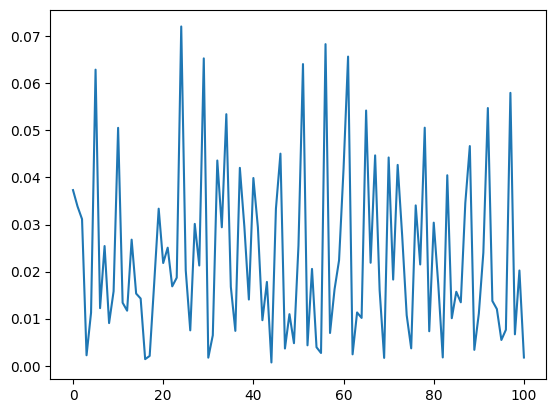

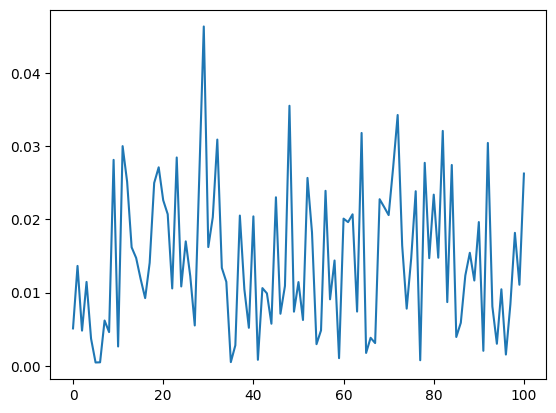

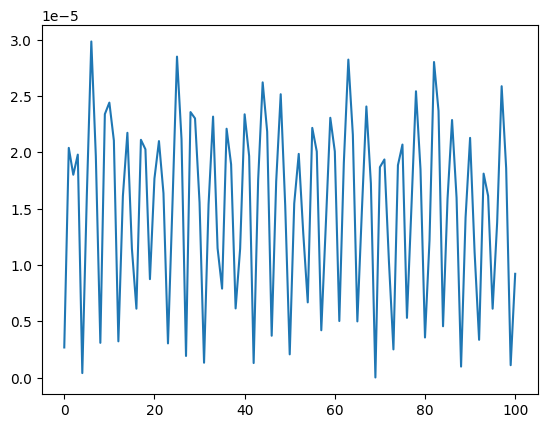

In [ ]:
plt.plot(resLon)
plt.show()
plt.plot(resLat)
plt.show()
plt.plot(resMDist)
plt.show()


In [ ]:
# ------------------------------------------------------------
# COMPARISON - FROM 50 YEARS BEFORE 2000 UP TO 50 YEARS AFTER
# ***************** topographic=True *********************
# Metric: ME (Mean Error) NOT MAE
# ------------------------------------------------------------

HOUR, MINUTE = 12, 0
print(YEAR, MONTH, DAY)
d=datetime(YEAR, MONTH, DAY, HOUR, MINUTE, 0)

res=[]

for y in (range(1950,2051)):
    m=1
    d=1
    f = datetime(y, m, d)


    # -------------------------
    # solarsystem values
    # -------------------------

    ss_moon = solarsystem.Moon(year=f.year, month=f.month, day=f.day, hour=HOUR, minute=MINUTE,
                         UT=0, dst=0, longtitude=LONGITUDE, latitude=LATITUDE, topographic=True)

    moon_lon, moon_lat, moon_r = ss_moon.position()



    # ==========================================
    # # skyfield moon
    # # ==========================================

    t = ts.utc(f.year, f.month, f.day, HOUR, MINUTE)

    bluffton = wgs84.latlon(LATITUDE , LONGITUDE)
    observer = eph['Earth'] + bluffton


    moon = eph['Moon']

    apparent = observer.at(t).observe(moon).apparent()

    ra, dec, distance = apparent.radec(epoch=t)
    ra, dec = ra.degrees, dec.degrees
    lat_sk= apparent.ecliptic_latlon(epoch=t)[0].degrees
    lon_sk= apparent.ecliptic_latlon(epoch=t)[1].degrees
    dist_sk= apparent.ecliptic_latlon(epoch=t)[2].au


    # -------------------------
    # errors
    # -------------------------
    moon_lon=normalize(moon_lon)
    lon_sk=normalize(lon_sk)

    lon_error = (moon_lon - lon_sk)
    # lon_error = abs(moon_lon - ra)

    # # handle wrap-around
    if lon_error > 180:
        lon_error = 360 - lon_error
    if lon_error < -180:
        lon_error = lon_error -360


    # lat_error = abs(ss_lat - sf_lat)
    lat_error = (moon_lat - lat_sk)
    # moon distance from times Earth's radius to AU
    moon_r=moon_r*(6378127)/1.496e+11
    dist_error = (moon_r - dist_sk)
    dist_error_pc=100*dist_error/dist_sk

    # dist_error = abs(ss_r - sf_r)
    res.append([lon_error, lat_error, dist_error, dist_error_pc])

res=np.vstack(res)
res.shape

2050 1 1


(101, 4)

In [ ]:
print('Moon Longitude ME mean:', np.round(np.array(res[:,0]).mean(),6), 'degrees')
print('Moon Longitude ME max :', np.round(np.array(res[:,0]).max(),6), 'degrees')
print('Moon Longitude ME std :', np.round(np.array(res[:,0]).std(),6), 'degrees')
print('-----------------------------------------')
print('Moon Latitude ME  mean:', np.round(np.array(res[:,1]).mean(),6), 'degrees')
print('Moon Latitude ME  max :', np.round(np.array(res[:,1]).max(),6), 'degrees')
print('Moon Latitude ME  std :', np.round(np.array(res[:,2]).std(),6), 'degrees')
print('-----------------------------------------')
print('Moon distance ME  mean:', np.round(np.array(res[:,2]).mean(),12), 'AU')
print('Moon distance ME  max :', np.round(np.array(res[:,2]).max(),12), 'AU')
print('Moon distance ME  std :', np.round(np.array(res[:,2]).std(),12), 'AU')
print('Moon distance ME  mean PC:', np.round(np.array(res[:,3]).mean(),12), '%')


Moon Longitude ME mean: -0.012563 degrees
Moon Longitude ME max : 0.044686 degrees
Moon Longitude ME std : 0.026866 degrees
-----------------------------------------
Moon Latitude ME  mean: 5e-06 degrees
Moon Latitude ME  max : 0.046329 degrees
Moon Latitude ME  std : 1.7e-05 degrees
-----------------------------------------
Moon distance ME  mean: -5.35131e-07 AU
Moon distance ME  max : 2.5880263e-05 AU
Moon distance ME  std : 1.7043127e-05 AU
Moon distance ME  mean PC: -0.016206048671 %


In [ ]:
print('lon',demical2arcs(np.array(res[:,0]).mean()),demical2arcs(np.array(res[:,0]).max()),demical2arcs(np.array(res[:,0]).std()))
print('lat',demical2arcs(np.array(res[:,1]).mean()),demical2arcs(np.array(res[:,1]).max()),demical2arcs(np.array(res[:,1]).std()))

lon 0° 0.75' 0° 2.68' 0° 1.61'
lat 0° 0.0' 0° 2.78' 0° 1.05'
